## Tools Setup

In [1]:
import pathlib, os, sys, operator, re, datetime
from functools import reduce
import numpy as np
import tensorflow as tf
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
from tensorflow import keras
from keras import Model
import tensorflow_datasets as tfds
from tiny_imagenet import TinyImagenetDataset

# Enable or disable GPU
# To fully disable it, we need to hide all GPU devices from Tensorflow
# Make sure GPU is disabled for this inference part of the lab
ENABLE_GPU = True
# tf.debugging.set_log_device_placement(True)

if not ENABLE_GPU:
    tf.config.set_visible_devices([], 'GPU')

# Print Python and TF version, and where we are running
print(f'Running on Python Version: {sys.version}')
print(f'Using Tensorflow Version: {tf. __version__}')
if not tf.config.experimental.list_physical_devices("GPU"):
    print('Running on CPU')
else:
    print(f'Using GPU at: {tf.test.gpu_device_name()} (of {len(tf.config.experimental.list_physical_devices("GPU"))} available)')

2025-09-08 12:29:54.097291: I tensorflow/core/util/port.cc:113] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-09-08 12:29:54.109398: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:479] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2025-09-08 12:29:54.127605: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:10575] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2025-09-08 12:29:54.127648: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1442] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2025-09-08 12:29:54.138696: I tensorflow/core/platform/cpu_feature_gua

Running on Python Version: 3.9.21 (main, Feb 10 2025, 00:00:00) 
[GCC 11.5.0 20240719 (Red Hat 11.5.0-5)]
Using Tensorflow Version: 2.16.2
Using GPU at: /device:GPU:0 (of 1 available)


2025-09-08 12:29:59.165295: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:998] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-L355
2025-09-08 12:29:59.187061: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:998] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-L355
2025-09-08 12:29:59.187203: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:998] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-

## Dataset Inspection

In [2]:
# This cell imports our dataset.

# Original Source: https://github.com/ksachdeva/tiny-imagenet-tfds
# Class Version Source: https://github.com/duweisu/tiny-imagenet-tfds
# Setup our dataset
# ---------------------------------------------------------

tiny_imagenet_builder = TinyImagenetDataset()

# this call (download_and_prepare) will trigger the download of the dataset
# and preparation (conversion to tfrecords)
#
# This will be done only once and on next usage tfds will
# use the cached version on your host.
tiny_imagenet_builder.download_and_prepare(download_dir="~/tensorflow-datasets/downloads")

# class_names = tiny_imagenet_builder.info.features['label'].names
ds = tiny_imagenet_builder.as_dataset()
ds_train, ds_val = ds["train"], ds["validation"]
assert(isinstance(ds_train, tf.data.Dataset))
assert(isinstance(ds_val, tf.data.Dataset))

# Training Dataset
ds_train = ds_train.shuffle(1024).prefetch(tf.data.AUTOTUNE)

# Validation Dataset
ds_val = ds_val.shuffle(1024).prefetch(tf.data.AUTOTUNE)

# Dataset metadata
ds_info = tiny_imagenet_builder.info

2025-09-08 12:29:59.253286: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:998] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-L355
2025-09-08 12:29:59.253416: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:998] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-L355
2025-09-08 12:29:59.253484: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:998] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-

In [3]:
# We need to read the "human readable" labels so we can translate with the numeric values
# Read the labels file (words.txt)
with open(os.path.abspath('wnids.txt'), 'r') as f:
    wnids = [x.strip() for x in f]

# Map wnids to integer labels
wnid_to_label = {wnid: i for i, wnid in enumerate(wnids)}
label_to_wnid = {v: k for k, v in wnid_to_label.items()}

# Use words.txt to get names for each class
with open(os.path.abspath('words.txt'), 'r') as f:
    wnid_to_words = dict(line.split('\t') for line in f)
    for wnid, words in wnid_to_words.items():
        wnid_to_words[wnid] = [w.strip() for w in words.split(',')]
        
class_names = [str(wnid_to_words[wnid]) for wnid in wnids]

In [4]:
# Helper function to get the label name
def img_class(img_data, idx=None):
    image, label, id, label_name = img_data["image"], img_data["label"], img_data["id"], img_data["metadata"]['label_name']
    # Handle batches of images correctly
    if idx != None:
        image, label, id, label_name = img_data["image"][idx], img_data["label"][idx], img_data["id"][idx], img_data["metadata"]['label_name'][idx]
    
    return f"{label_name} (class index: {label} - id: {id})"


# Helper function to show basic info about an image
def img_info(img, idx=None, display=True, title_apend=""):
    image = img['image']

    # Print the class
    class_str = img_class(img, idx)
    print(f"Label: {class_str}")
    
    # Display the image
    if display:
        plt.figure()
        plt.title(title_apend + class_str)
        # Handle batches correctly
        if image.shape.ndims > 3:
            plt.imshow(image.numpy().reshape(64, 64, 3))
        else:
            plt.imshow(image.numpy())

--- Train & Validation dataset info ---
Train: <_PrefetchDataset element_spec={'id': TensorSpec(shape=(), dtype=tf.string, name=None), 'image': TensorSpec(shape=(64, 64, 3), dtype=tf.uint8, name=None), 'label': TensorSpec(shape=(), dtype=tf.int64, name=None), 'metadata': {'label_name': TensorSpec(shape=(), dtype=tf.string, name=None)}}>
Validation: <_PrefetchDataset element_spec={'id': TensorSpec(shape=(), dtype=tf.string, name=None), 'image': TensorSpec(shape=(64, 64, 3), dtype=tf.uint8, name=None), 'label': TensorSpec(shape=(), dtype=tf.int64, name=None), 'metadata': {'label_name': TensorSpec(shape=(), dtype=tf.string, name=None)}}>

--- Show an example image ---
Label: b'orange' (class index: 149 - id: b'n07747607')

 Show some other examples


2025-09-08 12:29:59.539604: W tensorflow/core/kernels/data/cache_dataset_ops.cc:858] The calling iterator did not fully read the dataset being cached. In order to avoid unexpected truncation of the dataset, the partially cached contents of the dataset  will be discarded. This can happen if you have an input pipeline similar to `dataset.cache().take(k).repeat()`. You should use `dataset.take(k).cache().repeat()` instead.
2025-09-08 12:29:59.559024: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence
2025-09-08 12:29:59.643395: W tensorflow/core/kernels/data/cache_dataset_ops.cc:858] The calling iterator did not fully read the dataset being cached. In order to avoid unexpected truncation of the dataset, the partially cached contents of the dataset  will be discarded. This can happen if you have an input pipeline similar to `dataset.cache().take(k).repeat()`. You should use `dataset.take(k).cache().repeat()` instead.

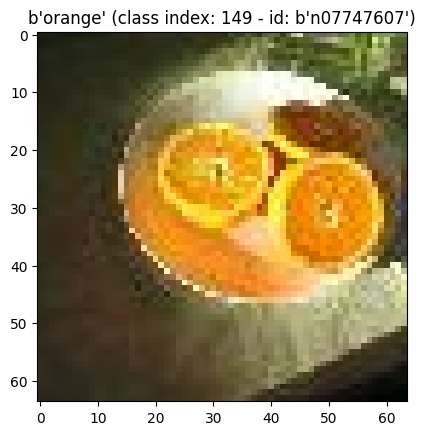

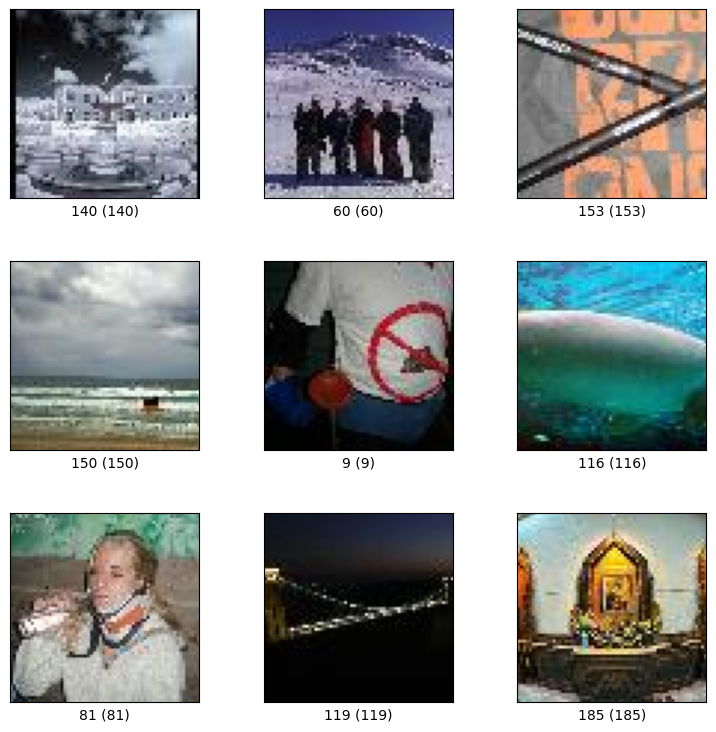

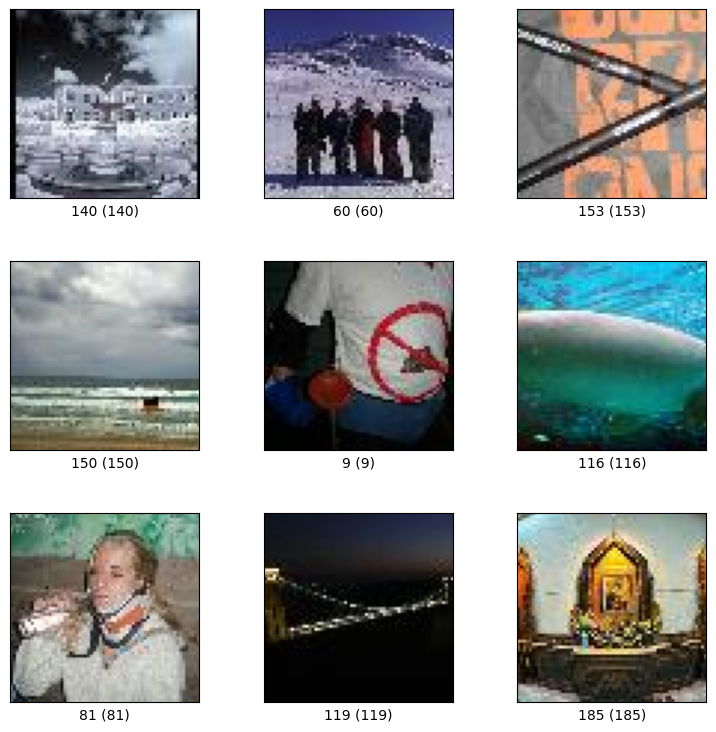

In [5]:
# Print the dataset types and info
print("--- Train & Validation dataset info ---")
print(f"Train: {ds_train}")
print(f"Validation: {ds_val}")
# print(f"Dataset Info: {ds_info}") # Uncomment to print Dataset info

print("\n--- Show an example image ---")
for example in ds_val.take(1):
    img_info(example)

print("\n Show some other examples")
tfds.show_examples(ds_val, ds_info, rows=3, cols=3)


--- Image 0 ---
Label: b'dugong, Dugong dugon' (class index: 116 - id: b'n02074367')
Image Shape - (64, 64, 3)
Image Dimensions - 3
Image Storage - <dtype: 'uint8'>
Label Index - 116
Id - b'n02074367'
Size - 12288 Bytes

--- Image 1 ---
Label: b'plate' (class index: 143 - id: b'n07579787')
Image Shape - (64, 64, 3)
Image Dimensions - 3
Image Storage - <dtype: 'uint8'>
Label Index - 143
Id - b'n07579787'
Size - 12288 Bytes

--- Image 2 ---
Label: b'trilobite' (class index: 174 - id: b'n01768244')
Image Shape - (64, 64, 3)
Image Dimensions - 3
Image Storage - <dtype: 'uint8'>
Label Index - 174
Id - b'n01768244'
Size - 12288 Bytes


2025-09-08 12:30:00.506068: W tensorflow/core/kernels/data/cache_dataset_ops.cc:858] The calling iterator did not fully read the dataset being cached. In order to avoid unexpected truncation of the dataset, the partially cached contents of the dataset  will be discarded. This can happen if you have an input pipeline similar to `dataset.cache().take(k).repeat()`. You should use `dataset.take(k).cache().repeat()` instead.
2025-09-08 12:30:00.513842: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


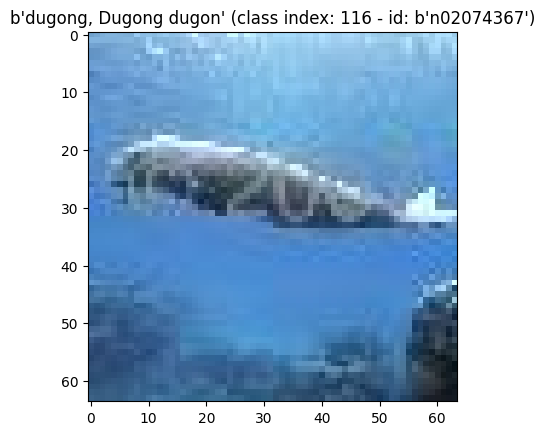

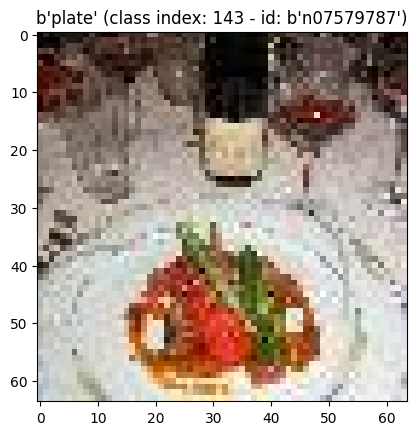

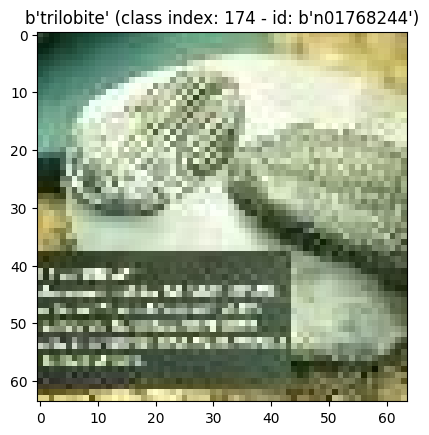

In [6]:
# TODO: Print and visualize three inputs from the validation set
#     : Print the stroage data type
#     : Print and note the dimensions of each image
#     : Print the memory required to store each image

# Sample Images
sample_imgs = []
for index, img_data in enumerate(ds_val.take(3)):
    sample_imgs.append(img_data)
    image, label, id, label_name = img_data["image"], img_data["label"], img_data["id"], img_data["metadata"]['label_name']

    print(f'\n--- Image {index} ---')
    # TODO: Your Code Here
    # See example usage: https://github.com/duweisu/tiny-imagenet-tfds
    img_info(img_data) # Print name of image as well as visualization
    #print(f"{image}")
    print(f"Image Shape - {image.shape}") # All images appear to be 3 dim
    print(f"Image Dimensions - {len(image.shape)}")
    print(f"Image Storage - {image.dtype}")
    print(f"Label Index - {label.numpy()}")
    print(f"Id - {id.numpy()}")
    print(f"Size - {image.shape[0] * image.shape[1] * image.shape[2]} Bytes") # could do a loop here for more consistency with larger matrices...

In [7]:
# TODO: Export each of the three inputs to a binary file which will be used to load the images into C++ later
# NOTE: First flatten the array (ex: 4D --> 1D). So 64*64*3 = 12288 element 1D array

# Make a directory for our image data
img_dir = os.path.abspath('img_data')
pathlib.Path(img_dir).mkdir(exist_ok=True)

# Create a metadata file
with open(os.path.join(img_dir, 'metadata.txt'), 'w') as metadata_file:
    metadata_file.write('Number\t\tDims\t\tClass Data\n')

for index, img_data in enumerate(sample_imgs):    

    image, label, id, label_name = img_data["image"], img_data["label"], img_data["id"], img_data["metadata"]['label_name']
    img_flat = image.numpy().flatten()
    
    # print index, shape and flattened length
    print(f"Image {index} shape: {image.shape}, flattened length: {len(img_flat)}")
    
    # 'wb' is write as a binary file
    with open(os.path.join(img_dir, f'image_{index}.bin'), 'wb') as img_file:
        img_flat.tofile(img_file)
    
    # 'a' mode in python is appending
    with open(os.path.join(img_dir, 'metadata.txt'), 'a') as metadata_file:
        metadata_file.write(f'{index}\t\t{image.shape}\t\t{label_name}\n')

Image 0 shape: (64, 64, 3), flattened length: 12288
Image 1 shape: (64, 64, 3), flattened length: 12288
Image 2 shape: (64, 64, 3), flattened length: 12288


## Model Loading and Inference

In [8]:
# TODO: Load the model
# Now we will load the H5 model! Please make sure the h5 model file is present in the below directory.
# You can download this from the Canvas Page and place it in the same directory as this notebook.

# model_path = os.path.abspath(""/home/<NETID>/path/to/your/lab1/CNN_TinyImageNet.h5)" # Uncomment this to use a non-relative path
model_path = os.path.abspath("CNN_TinyImageNet.h5")

# TODO: Your Code Here
model = tf.keras.models.load_model(model_path)
model.summary()

/home/tbibus/CprE587/lab01/cpre-487-587-lab1/lab1_venv/lib64/python3.9/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/home/tbibus/CprE587/lab01/cpre-487-587-lab1/lab1_venv/lib64/python3.9/site-packages/keras/src/optimizers/base_optimizer.py:86: UserWarning: Argument `decay` is no longer supported and will be ignored.
  warnings.warn(


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 60, 60, 32)     │         2,432 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 56, 56, 32)     │        25,632 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 28, 28, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 26, 26, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 24, 24, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 12, 12, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 10, 10, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 8, 8, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       524,544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 200)            │        51,400 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 770,218 (2.94 MB)

 Trainable params: 770,216 (2.94 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 2 (12.00 B)

2025-09-08 12:30:01.505222: W tensorflow/core/kernels/data/cache_dataset_ops.cc:858] The calling iterator did not fully read the dataset being cached. In order to avoid unexpected truncation of the dataset, the partially cached contents of the dataset  will be discarded. This can happen if you have an input pipeline similar to `dataset.cache().take(k).repeat()`. You should use `dataset.take(k).cache().repeat()` instead.


Label: [b'Labrador retriever'] (class index: [39] - id: [b'n02099712'])


I0000 00:00:1757352601.633373  128766 service.cc:145] XLA service 0x7f7f70007630 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1757352601.633407  128766 service.cc:153]   StreamExecutor device (0): NVIDIA A40-8Q, Compute Capability 8.6
2025-09-08 12:30:01.639562: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:268] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
2025-09-08 12:30:01.682660: I external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:465] Loaded cuDNN version 8907


1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 565ms/step
Best Guess [class index]: ['snorkel'] [111]
Best Guess Confidence (percent / 1.0): [0.56190544]
Top 15 Guesses (class index): ["['snorkel'] [111]", "['black stork', 'Ciconia nigra'] [115]", "['albatross', 'mollymawk'] [35]", "['goose'] [67]", "['binoculars', 'field glasses', 'opera glasses'] [197]", "['dumbbell'] [154]", "['magnetic compass'] [191]", "['syringe'] [162]", "['snail'] [33]", "['remote control', 'remote'] [54]", "['swimming trunks', 'bathing trunks'] [136]", "['bucket', 'pail'] [190]", "['bikini', 'two-piece'] [142]", "['gasmask', 'respirator', 'gas helmet'] [83]", "['acorn'] [195]"]
Top 15 Guesses Confidence (percent / 1.0): [[0.56190544 0.07275921 0.03228819 0.031647   0.02180277 0.02139886
  0.01891495 0.01872069 0.00884652 0.0081669  0.00779579 0.00758822
  0.00681273 0.00673694 0.00657327]]


I0000 00:00:1757352602.095536  128766 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.
2025-09-08 12:30:02.134232: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


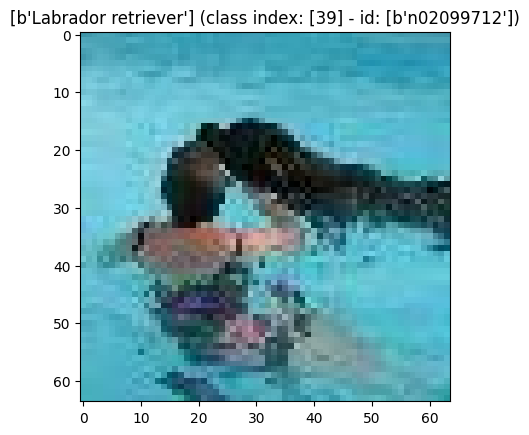

In [9]:
# Running infrence on our model
# We can run an infrence of our model by doing the following (we are doing batches of 1 here)
for example in ds_train.batch(1).take(1):
    img_info(example)
    
    # Make a prediction
    pred = model.predict(tf.cast(example["image"], tf.float32)/255.0)
    # print(f'Raw 200 Class Weighted Prediction:\n{pred}') # Uncomment to see the raw prediction
    
    # What is out best guess?
    best_guess = tf.math.argmax(pred, axis=1).numpy() # Our output is 200 weighted value, we want the most likely
    print(f'Best Guess [class index]: {class_names[best_guess[0]]} [{best_guess[0]}]')
    print(f'Best Guess Confidence (percent / 1.0): {pred[0][best_guess]}')

    # What are our top 15 guesses?
    top_15 = tf.math.top_k(pred, k=15)
    print(f'Top 15 Guesses (class index): {[f"{class_names[idx]} [{idx}]" for idx in top_15.indices[0]]}')
    print(f'Top 15 Guesses Confidence (percent / 1.0): {top_15.values}')

------------- Image 1 ----
Label: b'dugong, Dugong dugon' (class index: 116 - id: b'n02074367')
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step
Best Guess [class index]: ['alp'] [60]
Best Guess Confidence (percent / 1.0): [0.51806486]
Top 15 Guesses (class index): ["['alp'] [60]", "['American alligator', 'Alligator mississipiensis'] [160]", "['crane'] [103]", "['black stork', 'Ciconia nigra'] [115]", "['snorkel'] [111]", "['dugong', 'Dugong dugon'] [116]", "['syringe'] [162]", "['centipede'] [161]", "['albatross', 'mollymawk'] [35]", "['steel arch bridge'] [130]", "['sea cucumber', 'holothurian'] [37]", "['lakeside', 'lakeshore'] [56]", "['mantis', 'mantid'] [51]", "['black widow', 'Latrodectus mactans'] [141]", "['chain'] [171]"]
Top 15 Guesses Confidence (percent / 1.0): [[0.51806486 0.16286987 0.07291592 0.03848748 0.03651674 0.01611376
  0.01471755 0.01080083 0.00993178 0.00951513 0.00920609 0.00855567
  0.00729422 0.00716135 0.00714192]]
------------- Image 2 ----
Label: b'plate' (class ind

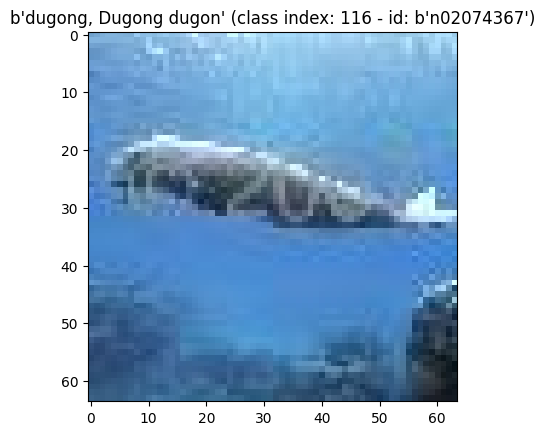

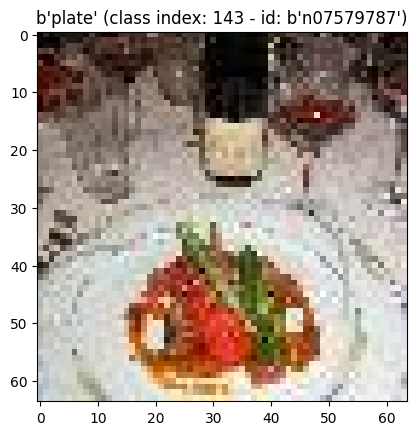

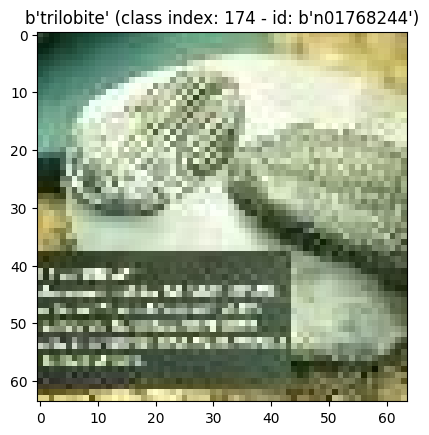

In [10]:
# TODO: Run infrence for our previous 3 sample images

# TODO: Your Code Here


for index, img_data in enumerate(sample_imgs): 
    print(f"------------- Image {index+1} ----")
    img_info(img_data)
    img = sample_imgs[index]["image"]
    normalized = tf.cast(img, tf.float32) / 255.0
    normalized = tf.expand_dims(normalized, axis=0)
    pred = model.predict(normalized)

    # What is out best guess?
    best_guess = tf.math.argmax(pred, axis=1).numpy() # Our output is 200 weighted value, we want the most likely
    print(f'Best Guess [class index]: {class_names[best_guess[0]]} [{best_guess[0]}]')
    print(f'Best Guess Confidence (percent / 1.0): {pred[0][best_guess]}')

    # What are our top 15 guesses?
    top_15 = tf.math.top_k(pred, k=15)
    print(f'Top 15 Guesses (class index): {[f"{class_names[idx]} [{idx}]" for idx in top_15.indices[0]]}')
    print(f'Top 15 Guesses Confidence (percent / 1.0): {top_15.values}')
    
    

In [11]:
# TODO: Calculate the Top-1, Top-5, and Top-10 Accuracy of the validation dataset
total = acc_top1 = acc_top5 = acc_top10 = 0
top1_correct = top5_correct = top10_correct = total_images = 0

total_images = 0

batch_size = 256

#ds_val = ds_val.batch(batch_size)
#ds_val = ds_val.prefetch(tf.data.AUTOTUNE)

# TODO: Your Code Here
for batch in ds_val.batch(batch_size).take(10000 // batch_size + 1):
    if(total_images >= 10000):
        break

    #print(f"images analyzed: {total_images}\n")
    images = batch["image"]
    labels = batch["label"]
    images = tf.cast(images, tf.float32) / 255.0

    #images = tf.expand_dims(images, axis=0)

    #pred = model.predict(tf.cast(example["image"], tf.float32)/255.0)
    # Make a prediction
    pred = model.predict(images, verbose=0)

    # Convert labels to int32 if one-hot encoded
    if len(labels.shape) > 1:  # Check if labels are one-hot
        labels = tf.argmax(labels, axis=1)
    labels = tf.cast(labels, tf.int32)  # Shape: (batch_size,)

    labels = tf.expand_dims(labels, axis=1)  # Shape: (batch_size, 1)

    #get correct counts

    top10 = tf.math.top_k(pred, k=10)
    top10_indices = top10.indices

    top1_matches = tf.reduce_any(tf.equal(labels, top10_indices[:, :1]))
    top1_correct += tf.reduce_sum(tf.cast(top1_matches, tf.int32)).numpy() 

    # Top-5 accuracy: True label in top-5 predictions
    top5_matches = tf.reduce_any(tf.equal(labels, top10_indices[:, :5]), axis=1)
    top5_correct += tf.reduce_sum(tf.cast(top5_matches, tf.int32)).numpy()
    
    # Top-10 accuracy: True label in top-10 predictions
    top10_matches = tf.reduce_any(tf.equal(labels, top10_indices), axis=1)
    top10_correct += tf.reduce_sum(tf.cast(top10_matches, tf.int32)).numpy()
    
    # Update total images
    total_images += batch_size

print(f"Total Images: {total_images}\n")
acc_top1 = top1_correct / total_images
acc_top5 = top5_correct / total_images
acc_top10 = top10_correct / total_images

total = (acc_top1 + acc_top5 + acc_top10) / 3.0

print(f"Top 1 Accuracy : {acc_top1 * 100.0}\n")
print(f"Top 5 Accuracy : {acc_top5 * 100.0}\n")
print(f"Top 10 Accuracy : {acc_top10 * 100.0}\n")
print(f"Total Accuracy : {total * 100.0}\n")

    

    
    



I0000 00:00:1757352606.853796  130004 asm_compiler.cc:369] ptxas warning : Registers are spilled to local memory in function 'triton_gemm_dot_93', 16 bytes spill stores, 16 bytes spill loads



Total Images: 10240

Top 1 Accuracy : 0.390625

Top 5 Accuracy : 48.251953125

Top 10 Accuracy : 60.29296875

Total Accuracy : 36.31184895833333



2025-09-08 12:30:07.406203: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


In [12]:
# TODO: Print all of the possible classes of the dataset

# TODO: Your Code Here
train_labels = ds_train.map(lambda x: x['label']).batch(len(ds_train)).as_numpy_iterator().next()

print("classes in training dataset:\n")
print(np.unique(train_labels))

val_labels = ds_val.map(lambda x: x['label']).batch(len(ds_val)).as_numpy_iterator().next()

print("\nclasses in validation dataset:\n")
print(np.unique(val_labels))

classes in training dataset:

[  0   1   2   3   4   5   6   7   8   9  10  11  12  13  14  15  16  17
  18  19  20  21  22  23  24  25  26  27  28  29  30  31  32  33  34  35
  36  37  38  39  40  41  42  43  44  45  46  47  48  49  50  51  52  53
  54  55  56  57  58  59  60  61  62  63  64  65  66  67  68  69  70  71
  72  73  74  75  76  77  78  79  80  81  82  83  84  85  86  87  88  89
  90  91  92  93  94  95  96  97  98  99 100 101 102 103 104 105 106 107
 108 109 110 111 112 113 114 115 116 117 118 119 120 121 122 123 124 125
 126 127 128 129 130 131 132 133 134 135 136 137 138 139 140 141 142 143
 144 145 146 147 148 149 150 151 152 153 154 155 156 157 158 159 160 161
 162 163 164 165 166 167 168 169 170 171 172 173 174 175 176 177 178 179
 180 181 182 183 184 185 186 187 188 189 190 191 192 193 194 195 196 197
 198 199]

classes in validation dataset:

[  0   1   2   3   4   5   6   7   8   9  10  11  12  13  14  15  16  17
  18  19  20  21  22  23  24  25  26  27  28  29  3

## Model Exploration

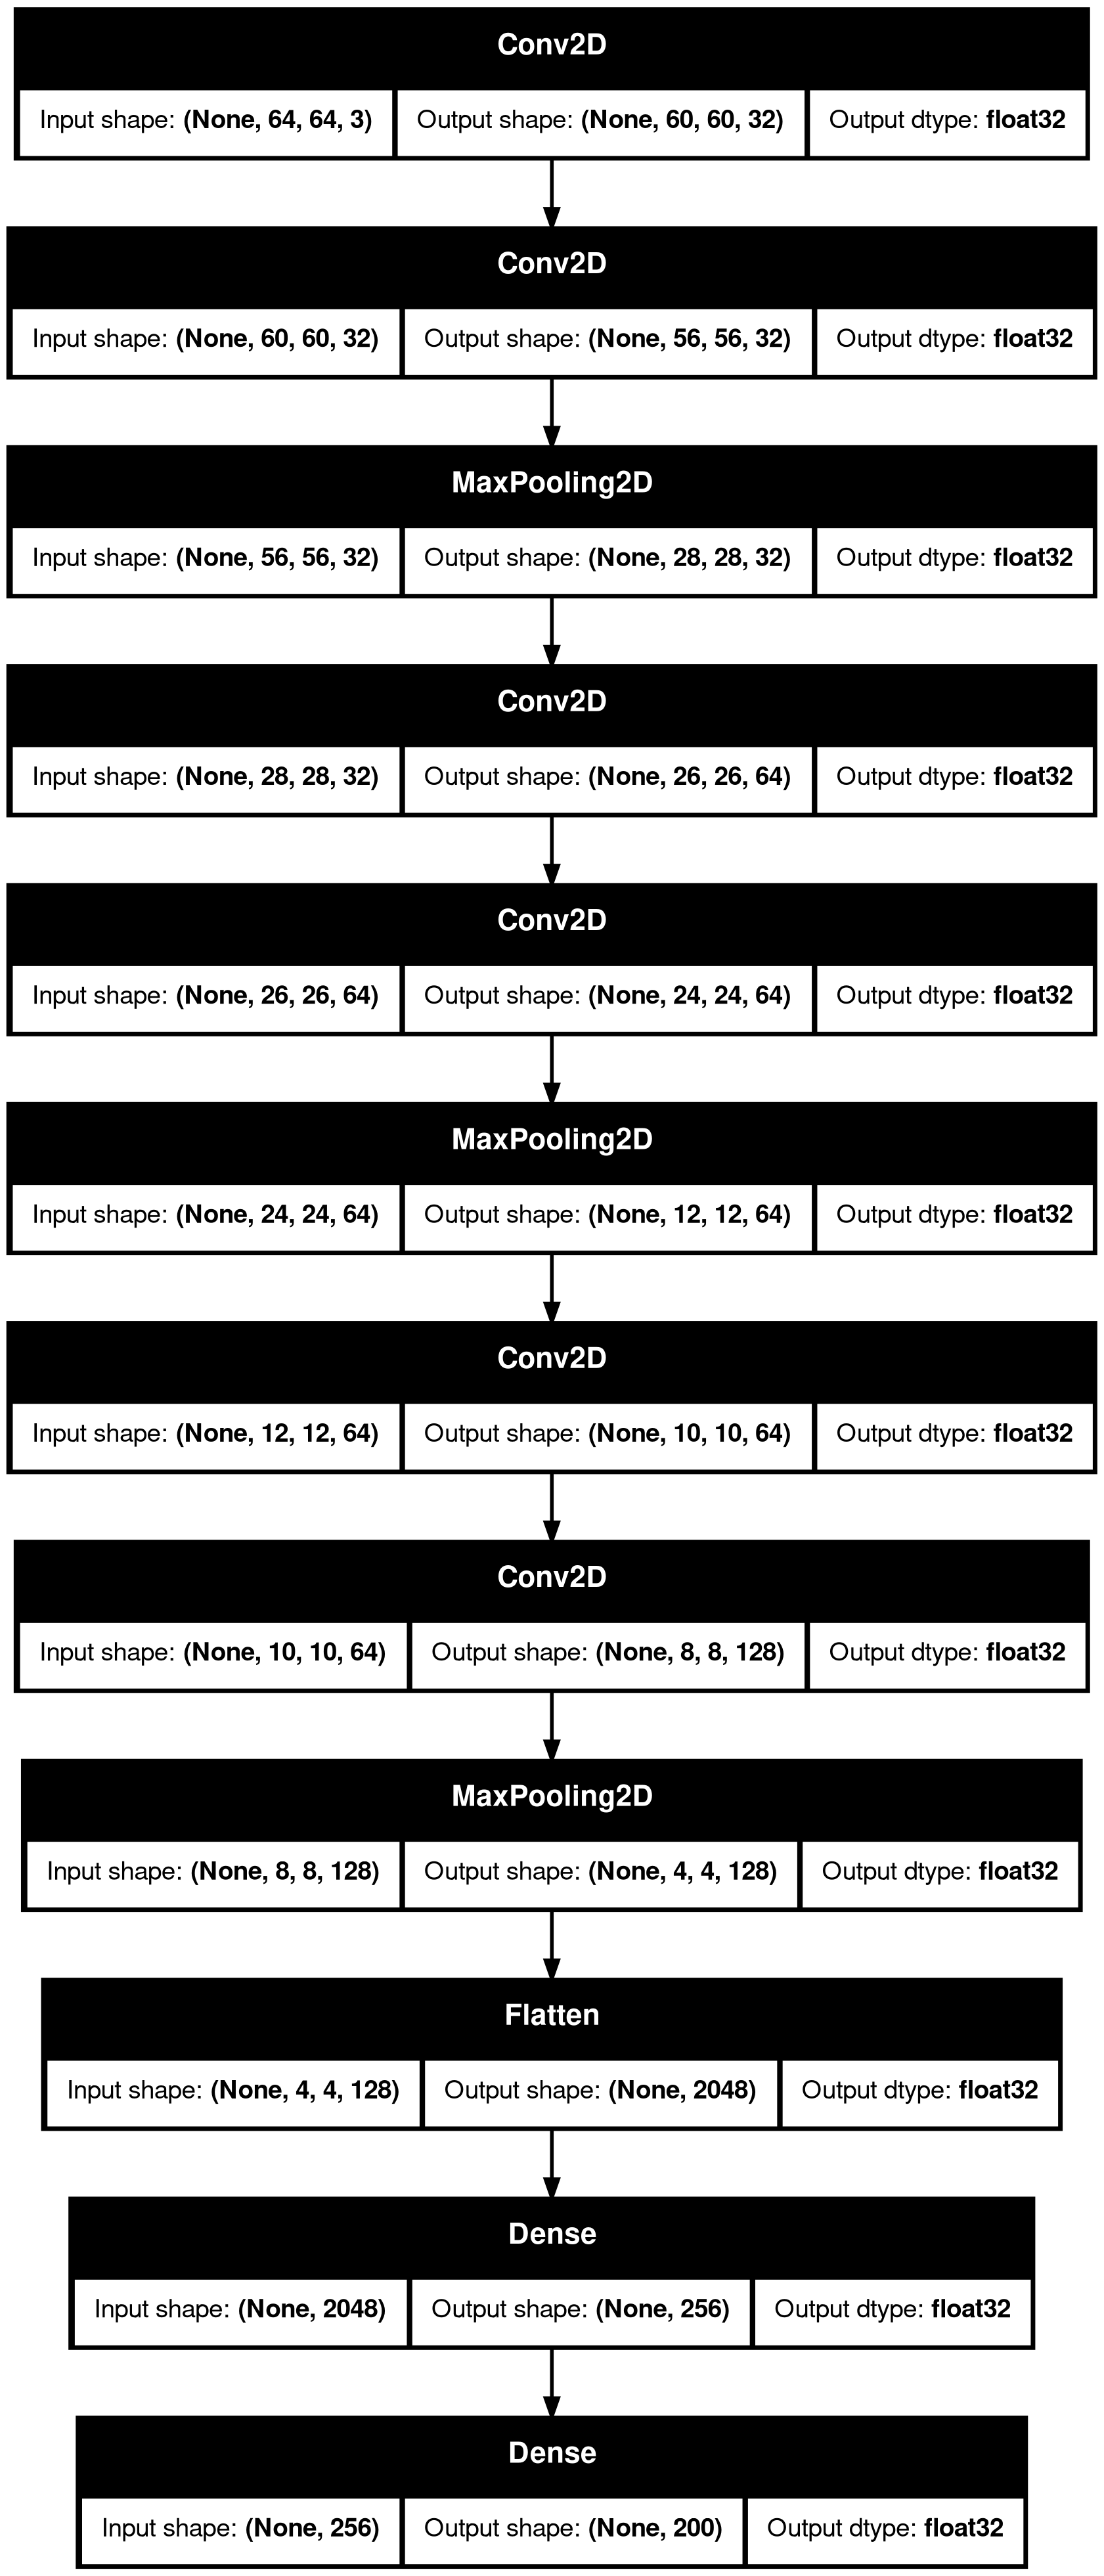

In [13]:
# TODO: Visualize the model in Netron (https://netron.app/) and include an image here.
tf.keras.utils.plot_model(model, "model.png", show_shapes=True, show_dtype=True, expand_nested=True) # Uncomment this to generate a simple visualization

conv2d: float32, Shape: (5, 5, 3, 32), Memory: 9.38 KB
conv2d_5: float32, Shape: (3, 3, 64, 128), Memory: 288.00 KB


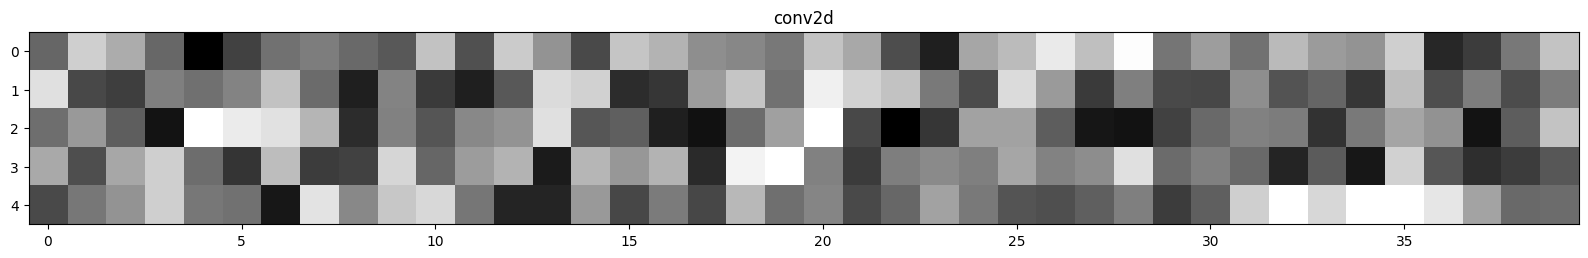

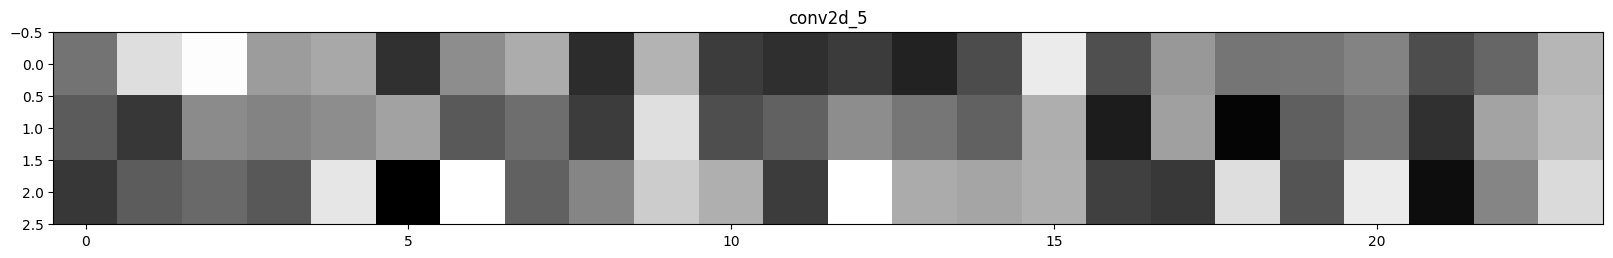

In [14]:
# We can view the layer weights. Here we consider them as images of feature filters applied to intermediate feature map images.
# TODO: Visualize the 2 convolutional layers filter sets (weights) (one at the beginning and one at the end)

# TODO: Your Code Here

layers = [layer for layer in model.layers]

first_layer, last_layer = layers[0], layers[-5] # first and last conv layer
first_weights, last_weights = first_layer.get_weights()[0], last_layer.get_weights()[0]

# vosializes the kernels in a belt form
def visualize_kernels(weights, layer_name):
    height, width, in_channels, out_channels = weights.shape # for weights we can just use shape outchannel (maybe we are meant to use the inchannel but idk for sure it's comprable)
    k = min(out_channels, 8) # min 8 increases the size for easier readability
    size = height
    
    # we need an empty belt (getting this right took forever)
    image_belt = np.zeros((size, size * k), dtype=np.uint8) # Image belt initialization credit to: Grok 3 (Debugged and initialized) [this wasn't included in the article >:(]
    
    # # from alayticsvidhya article
    for i in range(k):
        feature_image = np.mean(weights[:, :, :, i], axis=2) # axis 2 has weights
        feature_image -= feature_image.mean() 
        feature_image /= feature_image.std()
        feature_image *= 64
        feature_image += 128
        feature_image = np.clip(feature_image, 0, 255).astype('uint8')
        image_belt[:, i * size : (i + 1) * size] = feature_image
    
    # Print belt (from analyticsvidya article)
    scale = 20. / k
    plt.figure(figsize=(scale * k, scale))
    plt.title(layer_name)
    plt.grid(False)
    plt.imshow(image_belt, cmap='gray', aspect='auto')

# do both layers
visualize_kernels(first_weights, first_layer.name)
visualize_kernels(last_weights, last_layer.name)

#   print weigt details
def print_weight_details(weights, layer_name):
    dtype, shape = weights.dtype, weights.shape
    num_params = np.prod(shape)
    memory_bytes = num_params * 4
    print(f"{layer_name}: {dtype}, Shape: {shape}, Memory: {memory_bytes / 1024:.2f} KB")

print_weight_details(first_weights, first_layer.name)
print_weight_details(last_weights, last_layer.name)

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 777ms/step
conv2d: float32, Shape: (5, 5, 3, 32), Memory: 9.38 KB
conv2d_1: float32, Shape: (5, 5, 32, 32), Memory: 100.00 KB
conv2d_2: float32, Shape: (3, 3, 32, 64), Memory: 72.00 KB
conv2d_3: float32, Shape: (3, 3, 64, 64), Memory: 144.00 KB
conv2d_4: float32, Shape: (3, 3, 64, 64), Memory: 144.00 KB
conv2d_5: float32, Shape: (3, 3, 64, 128), Memory: 288.00 KB
dense: float32, Shape: (2048, 256), Memory: 2048.00 KB
dense_1: float32, Shape: (256, 200), Memory: 200.00 KB


/tmp/ipykernel_128718/3795407857.py:17: RuntimeWarning: invalid value encountered in divide
  feature_image/= feature_image.std ()
/tmp/ipykernel_128718/3795407857.py:20: RuntimeWarning: invalid value encountered in cast
  feature_image= np.clip(feature_image, 0, 255).astype('uint8')
2025-09-08 12:30:11.191780: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


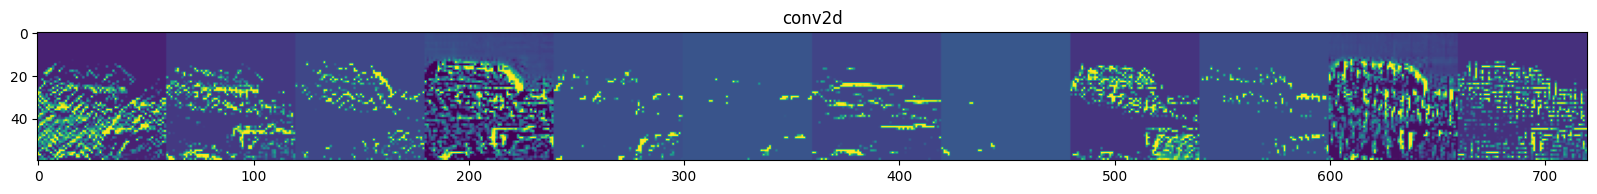

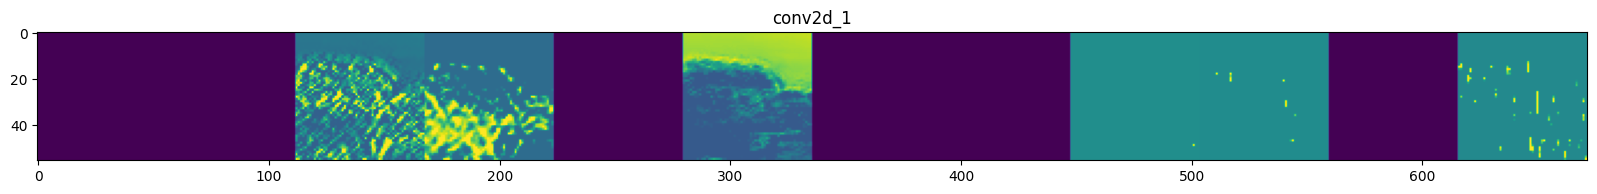

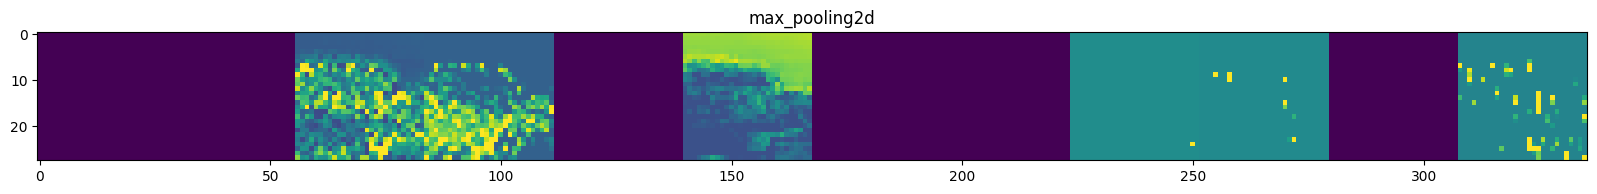

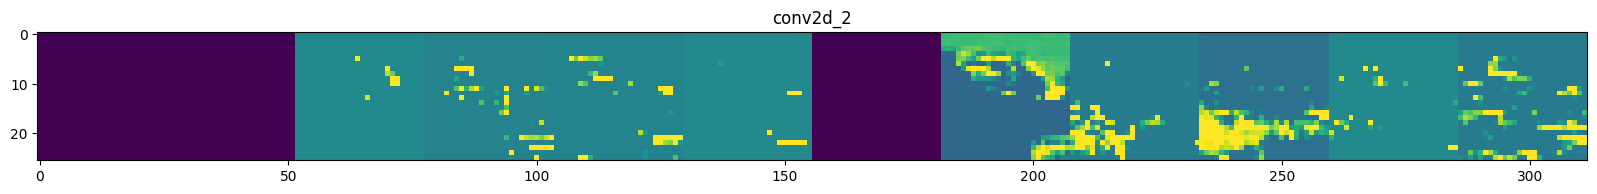

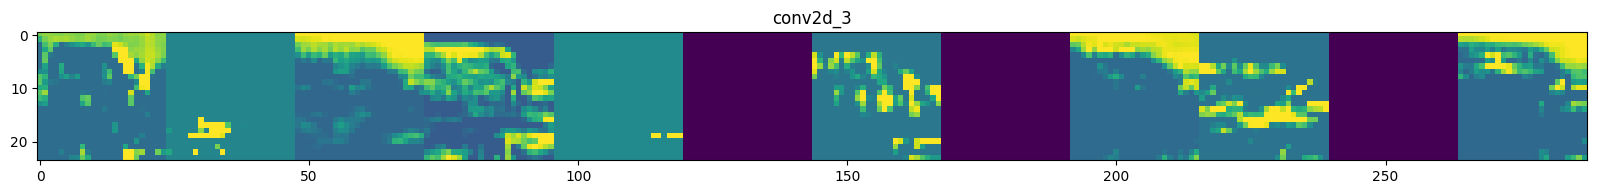

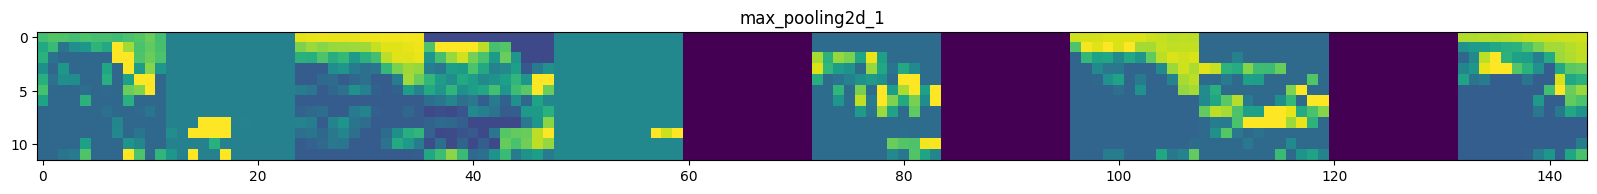

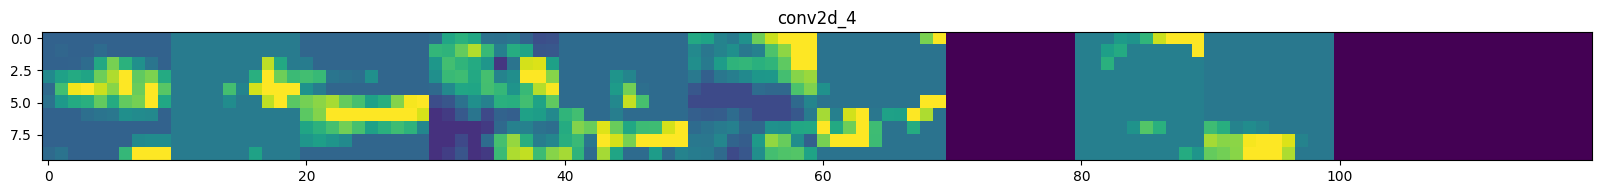

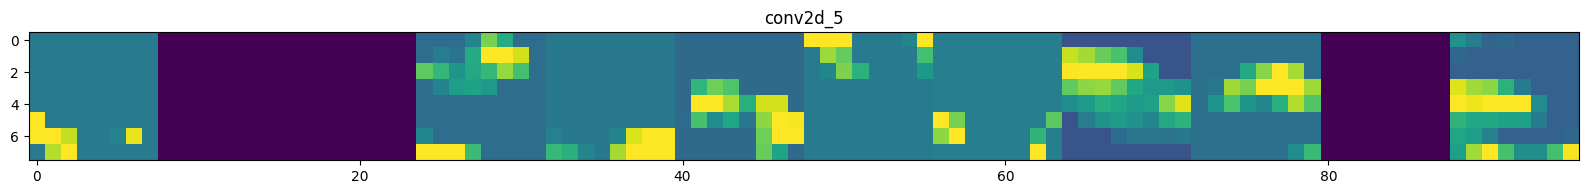

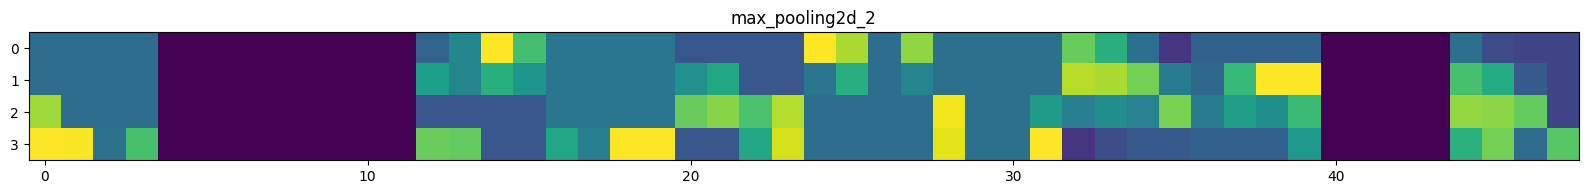

In [15]:
# We can view the layer outputs as well. Here we consider them as images of the spatial location of features.
# TODO: Visualize the 2 convolutional layers outputs (intermediate feature maps) (one at the beginning and one at the end)

# TODO: Your Code Here
def visualize_features(layer_name, feature_map): 
    for layer_name, feature_map in zip(layer_names, feature_maps): # Number of feature images/dimensions in a feature map of a layer 
        if len(feature_map.shape) != 4: 
            return
        k = min(feature_map.shape[-1], 12)  # Limit to 12 for readability
        size=feature_map.shape[1]
        image_belt = np.zeros((size, size * k), dtype=np.uint8)
    
        #iterating over a feature map of a particular layer to separate all feature images.    for i in range(k):
        for i in range(k):
            feature_image = feature_map[0, :, :, i]
            feature_image-= feature_image.mean()
            feature_image/= feature_image.std ()
            feature_image*=  64
            feature_image+= 128
            feature_image= np.clip(feature_image, 0, 255).astype('uint8')
            image_belt[:, i * size : (i + 1) * size] = feature_image

        scale = 20. / k
        plt.figure( figsize=(scale * k, scale) )
        plt.title ( layer_name )
        plt.grid  ( False )
        plt.imshow( image_belt, aspect='auto')


# get an image from ds_val


layer_names = [layer.name for layer in model.layers]
layer_outputs = [layer.output for layer in model.layers]



feature_map_model = tf.keras.models.Model(inputs=model.inputs, outputs=layer_outputs)

for batch in ds_val.batch(1).take(1):
    input_img = batch["image"]
    input_img = tf.cast(input_img, tf.float32) / 255.0
    feature_maps = feature_map_model.predict(input_img)
    visualize_features(layer_names[4], feature_maps[4])

#   print weigt details
def print_weight_details(weights, layer_name):
    dtype, shape = weights.dtype, weights.shape
    num_params = np.prod(shape)
    memory_bytes = num_params * 4
    print(f"{layer_name}: {dtype}, Shape: {shape}, Memory: {memory_bytes / 1024:.2f} KB")

for layer in model.layers:
    if len(layer.get_weights()) == 0:
        continue
    weights = layer.get_weights()[0]
    layer_name = layer.name
    print_weight_details(weights, layer_name)


In [16]:
# TODO: Export the filters/weights se we can use them later
# Make a directory for our image data
model_dir = os.path.abspath('model_data')
pathlib.Path(model_dir).mkdir(exist_ok=True)


# Export each image
conv_index = dense_index = 1 # layer index starts from one
for layer_idx, layer in enumerate(model.layers):
    if re.match(r'(conv|dense)', layer.name):
        weight_file_name = os.path.join(model_dir, f'{layer.name}_weights.bin')
        bias_file_name = os.path.join(model_dir, f'{layer.name}_bias.bin')
    else: continue

    assert layer.weights[0].name.endswith('kernel')
    assert layer.weights[1].name.endswith('bias')
        
    # TODO: Your Code Here
    weights = layer.get_weights()[0]
    biases = layer.get_weights()[1]
    weights_flat = weights.flatten()
    biases_flat = biases.flatten()
    with open(weight_file_name, 'wb') as weight_file:
        weights_flat.tofile(weight_file)
    with open(bias_file_name, 'wb') as bias_file:
        biases_flat.tofile(bias_file)
    print(f"Exported {layer.name} weights to {weight_file_name} and biases to {bias_file_name}")

Exported conv2d weights to /home/tbibus/CprE587/lab01/cpre-487-587-lab1/model_data/conv2d_weights.bin and biases to /home/tbibus/CprE587/lab01/cpre-487-587-lab1/model_data/conv2d_bias.bin
Exported conv2d_1 weights to /home/tbibus/CprE587/lab01/cpre-487-587-lab1/model_data/conv2d_1_weights.bin and biases to /home/tbibus/CprE587/lab01/cpre-487-587-lab1/model_data/conv2d_1_bias.bin
Exported conv2d_2 weights to /home/tbibus/CprE587/lab01/cpre-487-587-lab1/model_data/conv2d_2_weights.bin and biases to /home/tbibus/CprE587/lab01/cpre-487-587-lab1/model_data/conv2d_2_bias.bin
Exported conv2d_3 weights to /home/tbibus/CprE587/lab01/cpre-487-587-lab1/model_data/conv2d_3_weights.bin and biases to /home/tbibus/CprE587/lab01/cpre-487-587-lab1/model_data/conv2d_3_bias.bin
Exported conv2d_4 weights to /home/tbibus/CprE587/lab01/cpre-487-587-lab1/model_data/conv2d_4_weights.bin and biases to /home/tbibus/CprE587/lab01/cpre-487-587-lab1/model_data/conv2d_4_bias.bin
Exported conv2d_5 weights to /home/t

In [17]:
# TODO: Export the intermediate layer outputs for each input image for all layers
img_dir = os.path.abspath('img_data')
pathlib.Path(img_dir).mkdir(exist_ok=True)

# Create a model that outputs all intermediate layers
feature_map_model = tf.keras.models.Model(inputs=model.inputs, outputs=layer_outputs)

for img_idx, img_data in enumerate(sample_imgs):
    file_dir = os.path.join(img_dir, f'test_input_{img_idx}')
    pathlib.Path(file_dir).mkdir(exist_ok=True)

    # prep image
    img = img_data["image"]
    input_img = tf.cast(img, tf.float32) / 255.0
    input_img = tf.expand_dims(input_img, axis=0)
    
    feature_maps = feature_map_model.predict(input_img)
    
    #   flatten and export feature maps
    for layer_idx, fmap in enumerate(feature_maps):
        layer_name = layer_names[layer_idx]
        fmap_flat = fmap.flatten()
        out_path = os.path.join(file_dir, f'{layer_name}_output.bin')
        with open(out_path, 'wb') as out_file:
            fmap_flat.tofile(out_file)
        print(f"exported {layer_name} output for image {img_idx} to {out_path}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 669ms/step
exported conv2d output for image 0 to /home/tbibus/CprE587/lab01/cpre-487-587-lab1/img_data/test_input_0/conv2d_output.bin
exported conv2d_1 output for image 0 to /home/tbibus/CprE587/lab01/cpre-487-587-lab1/img_data/test_input_0/conv2d_1_output.bin
exported max_pooling2d output for image 0 to /home/tbibus/CprE587/lab01/cpre-487-587-lab1/img_data/test_input_0/max_pooling2d_output.bin
exported conv2d_2 output for image 0 to /home/tbibus/CprE587/lab01/cpre-487-587-lab1/img_data/test_input_0/conv2d_2_output.bin
exported conv2d_3 output for image 0 to /home/tbibus/CprE587/lab01/cpre-487-587-lab1/img_data/test_input_0/conv2d_3_output.bin
exported max_pooling2d_1 output for image 0 to /home/tbibus/CprE587/lab01/cpre-487-587-lab1/img_data/test_input_0/max_pooling2d_1_output.bin
exported conv2d_4 output for image 0 to /home/tbibus/CprE587/lab01/cpre-487-587-lab1/img_data/test_input_0/conv2d_4_output.bin
exported conv2d_5 output for image 0 to /home/tbibus

## Tensorboard

In [18]:
# Setup for profiling
tf.profiler.experimental.ProfilerOptions(
    host_tracer_level=1, python_tracer_level=0, device_tracer_level=1
)

log_dir = os.path.abspath(os.path.join('log_data'))
log_dir_run = os.path.abspath(os.path.join(log_dir, datetime.datetime.now().strftime("%Y%m%d-%H%M%S")))
pathlib.Path(log_dir_run).mkdir(exist_ok=True, parents=True)

try:
    tf.profiler.experimental.stop()
except:
    test = 2
finally:
    test = 1

In [19]:
# TODO: Sample Profiling - Inference for a single image:

# Define inference step with tf.function for optimization

# I dont know what the hell to do here...
# Issue resolved, was not looking at the toolflow tool dropdown

@tf.function
def inference_step(image):
    return model(image)

tf.profiler.experimental.start(log_dir_run)

for img_data in ds_val.take(3): 
    img = img_data["image"] 
    img = tf.cast(img, tf.float32) / 255.0 
    img = tf.expand_dims(img, axis=0)  
    inference_step(img)  
    print("image done")

tf.profiler.experimental.stop()

2025-09-08 12:30:13.063784: I external/local_tsl/tsl/profiler/lib/profiler_session.cc:104] Profiler session initializing.
2025-09-08 12:30:13.063816: I external/local_tsl/tsl/profiler/lib/profiler_session.cc:119] Profiler session started.
2025-09-08 12:30:13.063852: I external/local_xla/xla/backends/profiler/gpu/cupti_tracer.cc:1239] Profiler found 1 GPUs
2025-09-08 12:30:13.064291: E external/local_xla/xla/backends/profiler/gpu/cupti_error_manager.cc:137] cuptiGetTimestamp: error 999: 
2025-09-08 12:30:13.064313: E external/local_xla/xla/backends/profiler/gpu/cupti_error_manager.cc:186] cuptiSubscribe: ignored due to a previous error.
2025-09-08 12:30:13.064319: E external/local_xla/xla/backends/profiler/gpu/cupti_error_manager.cc:223] cuptiGetResultString: ignored due to a previous error.
2025-09-08 12:30:13.064327: E external/local_xla/xla/backends/profiler/gpu/cupti_tracer.cc:1282] function cupti_interface_->Subscribe( &subscriber_, (CUpti_CallbackFunc)ApiCallback, this)failed with

image done
image done
image done


2025-09-08 12:30:13.362533: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence
2025-09-08 12:30:13.363581: I external/local_tsl/tsl/profiler/lib/profiler_session.cc:70] Profiler session collecting data.
2025-09-08 12:30:13.366383: E external/local_xla/xla/backends/profiler/gpu/cupti_error_manager.cc:142] cuptiFinalize: ignored due to a previous error.
2025-09-08 12:30:13.366404: E external/local_xla/xla/backends/profiler/gpu/cupti_error_manager.cc:223] cuptiGetResultString: ignored due to a previous error.
2025-09-08 12:30:13.366408: E external/local_xla/xla/backends/profiler/gpu/cupti_tracer.cc:1373] function cupti_interface_->Finalize()failed with error 
2025-09-08 12:30:13.375770: E external/local_xla/xla/backends/profiler/gpu/cupti_error_manager.cc:135] cuptiGetTimestamp: ignored due to a previous error.
2025-09-08 12:30:13.375794: E external/local_xla/xla/backends/profiler/gpu/cupti_error_manager.cc:135] cup

In [20]:
# Load the TensorBoard notebook extension.
%load_ext tensorboard

# Launch TensorBoard and navigate to the Profile tab to view performance profile. 
# *** Please note just execute this command once in a session and 
# then logs for subsequent runs would be auto detected in tensorboard- url: http://localhost:6006/
print(log_dir_run)
%tensorboard --logdir={log_dir_run} --port=6006

# You can view the tensorboard in the browser url: http://localhost:6006/

# Useful command line to have if tensorboard is misbehaving: kill $(ps -e | grep 'tensorboard' | awk '{print $1}')

/home/tbibus/CprE587/lab01/cpre-487-587-lab1/log_data/20250908-123013


ERROR: Failed to launch TensorBoard (exited with 255).
Contents of stderr:
/home/tbibus/CprE587/lab01/cpre-487-587-lab1/lab1_venv/lib64/python3.9/site-packages/tensorboard/default.py:30: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources
2025-09-08 12:30:14.423624: I tensorflow/core/util/port.cc:113] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-09-08 12:30:14.435892: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:479] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2025-09-08 12:30:14.453466: E external/local

In [21]:
# TODO: Sample Profiling - Online Inference:

# Vary this from 10, 100, 1000 to simulate multiple online inference
loop_index = [10, 100, 1000]

for idx in loop_index:

    tf.profiler.experimental.start(log_dir_run)

    for i in range(idx):
        # Actual online inference
        # TODO: Your Code Here
        for batch in ds_val.batch(1).take(1):
            image = batch["image"]
            image = tf.cast(image, tf.float32) / 255.0
            pred = model.predict(image)

    tf.profiler.experimental.stop() 




1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step


2025-09-08 12:30:17.464270: I external/local_tsl/tsl/profiler/lib/profiler_session.cc:104] Profiler session initializing.
2025-09-08 12:30:17.464296: I external/local_tsl/tsl/profiler/lib/profiler_session.cc:119] Profiler session started.
2025-09-08 12:30:17.464323: E external/local_xla/xla/backends/profiler/gpu/cupti_error_manager.cc:135] cuptiGetTimestamp: ignored due to a previous error.
2025-09-08 12:30:17.464332: E external/local_xla/xla/backends/profiler/gpu/cupti_error_manager.cc:186] cuptiSubscribe: ignored due to a previous error.
2025-09-08 12:30:17.464336: E external/local_xla/xla/backends/profiler/gpu/cupti_error_manager.cc:223] cuptiGetResultString: ignored due to a previous error.
2025-09-08 12:30:17.464340: E external/local_xla/xla/backends/profiler/gpu/cupti_tracer.cc:1282] function cupti_interface_->Subscribe( &subscriber_, (CUpti_CallbackFunc)ApiCallback, this)failed with error 
2025-09-08 12:30:17.542577: W tensorflow/core/framework/local_rendezvous.cc:404] Local ren

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step


2025-09-08 12:30:17.691979: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence
2025-09-08 12:30:17.765547: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence
2025-09-08 12:30:17.839690: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step


...

2025-09-08 12:31:38.198447: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence
2025-09-08 12:31:38.270365: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence
2025-09-08 12:31:38.344123: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step


2025-09-08 12:31:38.416517: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence
2025-09-08 12:31:38.488558: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence
2025-09-08 12:31:38.560134: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step


2025-09-08 12:31:38.631407: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence
2025-09-08 12:31:38.702882: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence
2025-09-08 12:31:38.775097: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence
2025-09-08 12:31:38.775899: I external/local_tsl/tsl/profiler/lib/profiler_session.cc:70] Profiler session collecting data.
2025-09-08 12:31:38.783654: E external/local_xla/xla/backends/profiler/gpu/cupti_error_manager.cc:142] cuptiFinalize: ignored due to a previous error.
2025-09-08 12:31:38.783680: E external/local_xla/xla/backends/profiler/gpu/cupti_error_manager.cc:223] cuptiGetResultString: ignored due to a previous error.
2025-09-08 12:31:38.783684: E external/local_xla/xla/backends/profiler/gpu/cupti_tracer.cc:1373] function cu

In [22]:
# TODO: Sample Profiling - Batch Inference:

# We would only perform batch inference for a subset of validation set i.e. 1000 images 
# using different batch sizes of 20, 40, 100, 200 

# Decides the size of the batch. Try: 20, 40, 100, 200
batch_size = [20, 40, 100, 200]

for batch in batch_size:
    # Starts Profile logging
    tf.profiler.experimental.start(log_dir_run)

    for batch in ds_val.batch(batch).take(1000 // batch):
        image = batch["image"]
        image = tf.cast(image, tf.float32) / 255.0
        pred = model.predict(image)

    tf.profiler.experimental.stop() 

2025-09-08 12:31:39.699239: I external/local_tsl/tsl/profiler/lib/profiler_session.cc:104] Profiler session initializing.
2025-09-08 12:31:39.699271: I external/local_tsl/tsl/profiler/lib/profiler_session.cc:119] Profiler session started.
2025-09-08 12:31:39.699287: E external/local_xla/xla/backends/profiler/gpu/cupti_error_manager.cc:135] cuptiGetTimestamp: ignored due to a previous error.
2025-09-08 12:31:39.699292: E external/local_xla/xla/backends/profiler/gpu/cupti_error_manager.cc:186] cuptiSubscribe: ignored due to a previous error.
2025-09-08 12:31:39.699295: E external/local_xla/xla/backends/profiler/gpu/cupti_error_manager.cc:223] cuptiGetResultString: ignored due to a previous error.
2025-09-08 12:31:39.699299: E external/local_xla/xla/backends/profiler/gpu/cupti_tracer.cc:1282] function cupti_interface_->Subscribe( &subscriber_, (CUpti_CallbackFunc)ApiCallback, this)failed with error 


1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 938ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
1/1 ━━━━━━━

2025-09-08 12:31:43.486335: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence
2025-09-08 12:31:43.487278: I external/local_tsl/tsl/profiler/lib/profiler_session.cc:70] Profiler session collecting data.
2025-09-08 12:31:43.492789: E external/local_xla/xla/backends/profiler/gpu/cupti_error_manager.cc:142] cuptiFinalize: ignored due to a previous error.
2025-09-08 12:31:43.492812: E external/local_xla/xla/backends/profiler/gpu/cupti_error_manager.cc:223] cuptiGetResultString: ignored due to a previous error.
2025-09-08 12:31:43.492817: E external/local_xla/xla/backends/profiler/gpu/cupti_tracer.cc:1373] function cupti_interface_->Finalize()failed with error 
2025-09-08 12:31:43.531007: E external/local_xla/xla/backends/profiler/gpu/cupti_error_manager.cc:135] cuptiGetTimestamp: ignored due to a previous error.
2025-09-08 12:31:43.531038: E external/local_xla/xla/backends/profiler/gpu/cupti_error_manager.cc:135] cup

2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 886ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step
1/4 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step

2025-09-08 12:31:45.993606: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence
2025-09-08 12:31:45.994434: I external/local_tsl/tsl/profiler/lib/profiler_session.cc:70] Profiler session collecting data.
2025-09-08 12:31:46.000492: E external/local_xla/xla/backends/profiler/gpu/cupti_error_manager.cc:142] cuptiFinalize: ignored due to a previous error.
2025-09-08 12:31:46.000513: E external/local_xla/xla/backends/profiler/gpu/cupti_error_manager.cc:223] cuptiGetResultString: ignored due to a previous error.
2025-09-08 12:31:46.000517: E external/local_xla/xla/backends/profiler/gpu/cupti_tracer.cc:1373] function cupti_interface_->Finalize()failed with error 
2025-09-08 12:31:46.037594: E external/local_xla/xla/backends/profiler/gpu/cupti_error_manager.cc:135] cuptiGetTimestamp: ignored due to a previous error.
2025-09-08 12:31:46.037620: E external/local_xla/xla/backends/profiler/gpu/cupti_error_manager.cc:135] cup

4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 283ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step 
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step 
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step 
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step 
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step 
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step 
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step 
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step 
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step 
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 


2025-09-08 12:31:47.593608: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence
2025-09-08 12:31:47.594546: I external/local_tsl/tsl/profiler/lib/profiler_session.cc:70] Profiler session collecting data.
2025-09-08 12:31:47.600914: E external/local_xla/xla/backends/profiler/gpu/cupti_error_manager.cc:142] cuptiFinalize: ignored due to a previous error.
2025-09-08 12:31:47.600938: E external/local_xla/xla/backends/profiler/gpu/cupti_error_manager.cc:223] cuptiGetResultString: ignored due to a previous error.
2025-09-08 12:31:47.600950: E external/local_xla/xla/backends/profiler/gpu/cupti_tracer.cc:1373] function cupti_interface_->Finalize()failed with error 
2025-09-08 12:31:47.634187: E external/local_xla/xla/backends/profiler/gpu/cupti_error_manager.cc:135] cuptiGetTimestamp: ignored due to a previous error.
2025-09-08 12:31:47.634210: E external/local_xla/xla/backends/profiler/gpu/cupti_error_manager.cc:135] cup

7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 


2025-09-08 12:31:48.069611: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence
2025-09-08 12:31:48.070555: I external/local_tsl/tsl/profiler/lib/profiler_session.cc:70] Profiler session collecting data.
2025-09-08 12:31:48.076735: E external/local_xla/xla/backends/profiler/gpu/cupti_error_manager.cc:142] cuptiFinalize: ignored due to a previous error.
2025-09-08 12:31:48.076755: E external/local_xla/xla/backends/profiler/gpu/cupti_error_manager.cc:223] cuptiGetResultString: ignored due to a previous error.
2025-09-08 12:31:48.076759: E external/local_xla/xla/backends/profiler/gpu/cupti_tracer.cc:1373] function cupti_interface_->Finalize()failed with error 
2025-09-08 12:31:48.106114: E external/local_xla/xla/backends/profiler/gpu/cupti_error_manager.cc:135] cuptiGetTimestamp: ignored due to a previous error.
2025-09-08 12:31:48.106136: E external/local_xla/xla/backends/profiler/gpu/cupti_error_manager.cc:135] cup

## Training

In [ ]:
# Setup for model training
from tensorflow.keras import Model, datasets
from tensorflow.keras.models import Sequential
from tensorflow.keras.losses import categorical_crossentropy
from tensorflow.keras.optimizers import SGD
from tensorflow.keras.layers import Dense, Flatten, Conv2D, AveragePooling2D, MaxPooling2D, ZeroPadding2D,Convolution2D, Activation, Dropout 
from keras.callbacks import ReduceLROnPlateau
from tensorflow.keras.metrics import TopKCategoricalAccuracy

train_dir = os.path.abspath(os.path.join('train_data', datetime.datetime.now().strftime("%Y%m%d-%H%M%S")))
pathlib.Path(train_dir).mkdir(exist_ok=True, parents=True)



# Using early stopping to monitor validation accuracy
callbacks = [
    tf.keras.callbacks.EarlyStopping(
        # Stop training when `val_loss` is no longer improving
        monitor="val_loss",
        # "no longer improving" being defined as "no better than 1e-2 less" CHANGED TO BE LESS SENSITIVE
        min_delta=1e-4,
        # "no longer improving" being further defined as "for at least 2 epochs"
        patience=2,
        verbose=1,
    ),
    tf.keras.callbacks.TensorBoard(log_dir=train_dir, histogram_freq=1)
]

In [ ]:
def new_model(): # CREATED THIS SO WE CAN GET NEW MODELS TO TRAIN FOR EACH NEW BATCH/EPOCH!!!
    # Basic CNN model
    train_model = Sequential()
    
    # conv1
    train_model.add(Conv2D(32, (5, 5), input_shape=(64, 64, 3), activation='relu'))
    train_model.add(Conv2D(32, (5,5),activation='relu'))
    train_model.add(MaxPooling2D(pool_size=(2, 2)))
    train_model.add(Conv2D(64, (3,3), activation='relu'))
    train_model.add(Conv2D(64, (3,3), activation='relu'))
    train_model.add(MaxPooling2D(pool_size=(2, 2)))
    train_model.add(Conv2D(64, (3,3), activation='relu'))
    train_model.add(Conv2D(128, (3,3), activation='relu'))
    train_model.add(MaxPooling2D(pool_size=(2, 2)))
    train_model.add(Flatten())
    
    # fc1
    train_model.add(Dense(256, activation='relu'))
    
    # fc2
    train_model.add(Dense(200, activation='softmax'))
    
    train_model.compile(loss='categorical_crossentropy', optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001), metrics=['accuracy', TopKCategoricalAccuracy(k=5, name='top_5_accuracy')]) #optimizer change to fix learning rate provided by Google Gemini 2.5 Flash
    # TODO: Consider looking at different optimizers and learning rate settings
    #train_model.summary() comment out for now
    return train_model

In [ ]:
# TODO: Attempt to train your own model with different batch sizes
# TODO: See how long this takes without a GPU on your VDI or 2050 Coover machines
# TODO: THEN log in to your GPU VM, set ENABLE_GPU = False in the very first cell, and re-run all above cells
# TODO: Make sure you have exported the LD_LIBRARY_PATH as the lab manual indicates

def normalize_img(image, label):
    return tf.cast(image, tf.float32) / 255., label

def to_categorical(image, label):
    label = tf.one_hot(tf.cast(label, tf.int32), 200)
    return tf.cast(image, tf.float32), tf.cast(label, tf.int64)

ds_re = tiny_imagenet_builder.as_dataset(as_supervised=True)
ds_retrain, ds_reval = ds_re["train"], ds_re["validation"]

ds_retrain = ds_retrain.cache().shuffle(1024)
ds_reval = ds_reval.cache().shuffle(1024)

ds_retrain = ds_retrain.map(normalize_img, num_parallel_calls=tf.data.AUTOTUNE)
ds_reval = ds_reval.map(normalize_img, num_parallel_calls=tf.data.AUTOTUNE)

ds_retrain = ds_retrain.map(to_categorical, num_parallel_calls=tf.data.AUTOTUNE)
ds_reval = ds_reval.map(to_categorical, num_parallel_calls=tf.data.AUTOTUNE)

epoch_size = 20

best_top1 = {'batch_size': None, 'accuracy': 0.0}
best_top5 = {'batch_size': None, 'accuracy': 0.0}

for batch_size in [32, 64, 128]:
    # Setup our batched datasets
    print(f"\nTraining with batch size: {batch_size}")
    # TODO: Your Code Here
    train_dataset = ds_retrain.batch(batch_size).prefetch(tf.data.AUTOTUNE)
    val_dataset = ds_reval.batch(batch_size).prefetch(tf.data.AUTOTUNE)

    train_model = new_model()

    history = train_model.fit(
            train_dataset,
            epochs=epoch_size,
            validation_data=val_dataset,
            callbacks=[callbacks], 
            verbose=1
        )
    last_val_top1_accuracy = history.history['val_accuracy'][-1]
    last_val_top5_accuracy = history.history['val_top_5_accuracy'][-1]
    
    # Get best top-1 overall (kind of inaccurate as the val accuracy drops off as overfitting occurs)
    if last_val_top1_accuracy > best_top1['accuracy']:
        best_top1['accuracy'] = last_val_top1_accuracy
        best_top1['batch_size'] = batch_size
    
    # Update best Top-5 accuracy (kind of inaccurate as the val accuracy drops off as overfitting occurs)
    if last_val_top5_accuracy > best_top5['accuracy']:
        best_top5['accuracy'] = last_val_top5_accuracy
        best_top5['batch_size'] = batch_size

print("\nSummary of Best Accuracies:")
print(f"Best Top-1 Validation Accuracy: {best_top1['accuracy']:.4f} (Batch Size: {best_top1['batch_size']})")
print(f"Best Top-5 Validation Accuracy: {best_top5['accuracy']:.4f} (Batch Size: {best_top5['batch_size']})")



Training with batch size: 32


/home/tbibus/CprE587/lab01/cpre-487-587-lab1/lab1_venv/lib64/python3.9/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/20
3125/3125 ━━━━━━━━━━━━━━━━━━━━ 21s 5ms/step - accuracy: 0.0178 - loss: 5.1202 - top_5_accuracy: 0.0689 - val_accuracy: 0.0637 - val_loss: 4.6708 - val_top_5_accuracy: 0.1968
Epoch 2/20
3125/3125 ━━━━━━━━━━━━━━━━━━━━ 15s 5ms/step - accuracy: 0.0760 - loss: 4.5669 - top_5_accuracy: 0.2182 - val_accuracy: 0.1042 - val_loss: 4.3266 - val_top_5_accuracy: 0.2841
Epoch 3/20
3125/3125 ━━━━━━━━━━━━━━━━━━━━ 16s 5ms/step - accuracy: 0.1212 - loss: 4.2298 - top_5_accuracy: 0.3006 - val_accuracy: 0.1398 - val_loss: 4.0970 - val_top_5_accuracy: 0.3313
Epoch 4/20
3125/3125 ━━━━━━━━━━━━━━━━━━━━ 15s 5ms/step - accuracy: 0.1531 - loss: 3.9947 - top_5_accuracy: 0.3586 - val_accuracy: 0.1566 - val_loss: 3.9622 - val_top_5_accuracy: 0.3721
Epoch 5/20
3125/3125 ━━━━━━━━━━━━━━━━━━━━ 15s 5ms/step - accuracy: 0.1857 - loss: 3.7927 - top_5_accuracy: 0.4073 - val_accuracy: 0.1763 - val_loss: 3.8363 - val_top_5_accuracy: 0.3979
Epoch 6/20
3125/3125 ━━━━━━━━━━━━━━━━━━━━ 15s 5ms/step - accuracy: 0.2115 -

I0000 00:00:1757352933.733971  173198 asm_compiler.cc:369] ptxas warning : Registers are spilled to local memory in function 'triton_gemm_dot_901', 124 bytes spill stores, 124 bytes spill loads

I0000 00:00:1757352933.804194  173200 asm_compiler.cc:369] ptxas warning : Registers are spilled to local memory in function 'triton_gemm_dot_901', 112 bytes spill stores, 112 bytes spill loads

I0000 00:00:1757352934.555475  173203 asm_compiler.cc:369] ptxas warning : Registers are spilled to local memory in function 'triton_gemm_dot_746', 312 bytes spill stores, 280 bytes spill loads

I0000 00:00:1757352934.966935  173197 asm_compiler.cc:369] ptxas warning : Registers are spilled to local memory in function 'triton_gemm_dot_746', 88 bytes spill stores, 88 bytes spill loads



1563/1563 ━━━━━━━━━━━━━━━━━━━━ 19s 8ms/step - accuracy: 0.0227 - loss: 5.1100 - top_5_accuracy: 0.0780 - val_accuracy: 0.0717 - val_loss: 4.6273 - val_top_5_accuracy: 0.2017
Epoch 2/20
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 11s 7ms/step - accuracy: 0.0818 - loss: 4.5378 - top_5_accuracy: 0.2240 - val_accuracy: 0.0990 - val_loss: 4.3920 - val_top_5_accuracy: 0.2626
Epoch 3/20
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 11s 7ms/step - accuracy: 0.1142 - loss: 4.2884 - top_5_accuracy: 0.2887 - val_accuracy: 0.1304 - val_loss: 4.1641 - val_top_5_accuracy: 0.3194
Epoch 4/20
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 11s 7ms/step - accuracy: 0.1442 - loss: 4.0714 - top_5_accuracy: 0.3413 - val_accuracy: 0.1580 - val_loss: 3.9821 - val_top_5_accuracy: 0.3690
Epoch 5/20
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 11s 7ms/step - accuracy: 0.1721 - loss: 3.8832 - top_5_accuracy: 0.3842 - val_accuracy: 0.1763 - val_loss: 3.8628 - val_top_5_accuracy: 0.3913
Epoch 6/20
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 11s 7ms/step - accuracy: 0.1953 - loss: 3.72

I0000 00:00:1757353100.037996  173978 asm_compiler.cc:369] ptxas warning : Registers are spilled to local memory in function 'triton_gemm_dot_746', 252 bytes spill stores, 220 bytes spill loads

I0000 00:00:1757353100.695030  173985 asm_compiler.cc:369] ptxas warning : Registers are spilled to local memory in function 'triton_gemm_dot_746', 88 bytes spill stores, 88 bytes spill loads

I0000 00:00:1757353100.805383  173982 asm_compiler.cc:369] ptxas warning : Registers are spilled to local memory in function 'triton_gemm_dot_901', 116 bytes spill stores, 116 bytes spill loads

I0000 00:00:1757353101.285273  173983 asm_compiler.cc:369] ptxas warning : Registers are spilled to local memory in function 'triton_gemm_dot_901', 4 bytes spill stores, 4 bytes spill loads



782/782 ━━━━━━━━━━━━━━━━━━━━ 17s 14ms/step - accuracy: 0.0175 - loss: 5.1513 - top_5_accuracy: 0.0687 - val_accuracy: 0.0511 - val_loss: 4.8074 - val_top_5_accuracy: 0.1636
Epoch 2/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 9s 11ms/step - accuracy: 0.0655 - loss: 4.6978 - top_5_accuracy: 0.1905 - val_accuracy: 0.0874 - val_loss: 4.4953 - val_top_5_accuracy: 0.2382
Epoch 3/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 9s 11ms/step - accuracy: 0.0995 - loss: 4.4100 - top_5_accuracy: 0.2588 - val_accuracy: 0.1105 - val_loss: 4.3107 - val_top_5_accuracy: 0.2835
Epoch 4/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 9s 11ms/step - accuracy: 0.1256 - loss: 4.2128 - top_5_accuracy: 0.3086 - val_accuracy: 0.1275 - val_loss: 4.1852 - val_top_5_accuracy: 0.3203
Epoch 5/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 9s 11ms/step - accuracy: 0.1498 - loss: 4.0531 - top_5_accuracy: 0.3462 - val_accuracy: 0.1520 - val_loss: 4.0277 - val_top_5_accuracy: 0.3619
Epoch 6/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 9s 11ms/step - accuracy: 0.1703 - loss: 3.9156 - top_5_

In [ ]:
# TODO: Train your model with 3 different numbers of epochs
batch_size = 32

# Setup your datasets
# TODO: Your Code Here
train_dataset = ds_retrain.batch(batch_size).prefetch(tf.data.AUTOTUNE)
val_dataset = ds_reval.batch(batch_size).prefetch(tf.data.AUTOTUNE)

for epoch_size in [3, 10, 100]:
    # Run training
    # TODO: Your Code Here
    train_model = new_model()

    history = train_model.fit(
            train_dataset,
            epochs=epoch_size,
            validation_data=val_dataset,
            callbacks=[callbacks], 
            verbose=1
        )
   
    # Save the cnn model
    train_model.save(os.path.join(log_dir, f'CNN_TinyImageNet_train_batch{batch_size}.h5'))
    last_val_top1_accuracy = history.history['val_accuracy'][-1]
    last_val_top5_accuracy = history.history['val_top_5_accuracy'][-1]
    
    # Update best Top-1 accuracy (kind of inaccurate as the val accuracy drops off as overfitting occurs)
    if last_val_top1_accuracy > best_top1['accuracy']:
        best_top1['accuracy'] = last_val_top1_accuracy
        best_top1['batch_size'] = batch_size
    
    # Update best Top-5 accuracy (kind of inaccurate as the val accuracy drops off as overfitting occurs)
    if last_val_top5_accuracy > best_top5['accuracy']:
        best_top5['accuracy'] = last_val_top5_accuracy
        best_top5['batch_size'] = batch_size

# Report the best overall accuracies
print("\nSummary of Best Accuracies:")
print(f"Best Top-1 Validation Accuracy: {best_top1['accuracy']:.4f} (Batch Size: {best_top1['batch_size']})")
print(f"Best Top-5 Validation Accuracy: {best_top5['accuracy']:.4f} (Batch Size: {best_top5['batch_size']})")

Epoch 1/3
3125/3125 ━━━━━━━━━━━━━━━━━━━━ 18s 5ms/step - accuracy: 0.0205 - loss: 5.1059 - top_5_accuracy: 0.0756 - val_accuracy: 0.0752 - val_loss: 4.5527 - val_top_5_accuracy: 0.2180
Epoch 2/3
3125/3125 ━━━━━━━━━━━━━━━━━━━━ 15s 5ms/step - accuracy: 0.0871 - loss: 4.4696 - top_5_accuracy: 0.2393 - val_accuracy: 0.1202 - val_loss: 4.2277 - val_top_5_accuracy: 0.3005
Epoch 3/3
3125/3125 ━━━━━━━━━━━━━━━━━━━━ 15s 5ms/step - accuracy: 0.1308 - loss: 4.1346 - top_5_accuracy: 0.3244 - val_accuracy: 0.1488 - val_loss: 3.9844 - val_top_5_accuracy: 0.3595


Epoch 1/10
3125/3125 ━━━━━━━━━━━━━━━━━━━━ 18s 5ms/step - accuracy: 0.0213 - loss: 5.1100 - top_5_accuracy: 0.0768 - val_accuracy: 0.0757 - val_loss: 4.5948 - val_top_5_accuracy: 0.2076
Epoch 2/10
3125/3125 ━━━━━━━━━━━━━━━━━━━━ 15s 5ms/step - accuracy: 0.0852 - loss: 4.4849 - top_5_accuracy: 0.2360 - val_accuracy: 0.1160 - val_loss: 4.2327 - val_top_5_accuracy: 0.2980
Epoch 3/10
3125/3125 ━━━━━━━━━━━━━━━━━━━━ 15s 5ms/step - accuracy: 0.1261 - loss: 4.1576 - top_5_accuracy: 0.3180 - val_accuracy: 0.1409 - val_loss: 4.0571 - val_top_5_accuracy: 0.3411
Epoch 4/10
3125/3125 ━━━━━━━━━━━━━━━━━━━━ 15s 5ms/step - accuracy: 0.1610 - loss: 3.9241 - top_5_accuracy: 0.3744 - val_accuracy: 0.1669 - val_loss: 3.9041 - val_top_5_accuracy: 0.3794
Epoch 5/10
3125/3125 ━━━━━━━━━━━━━━━━━━━━ 15s 5ms/step - accuracy: 0.1919 - loss: 3.7339 - top_5_accuracy: 0.4210 - val_accuracy: 0.1853 - val_loss: 3.7713 - val_top_5_accuracy: 0.4114
Epoch 6/10
3125/3125 ━━━━━━━━━━━━━━━━━━━━ 15s 5ms/step - accuracy: 0.2174 -

Epoch 1/100
3125/3125 ━━━━━━━━━━━━━━━━━━━━ 18s 5ms/step - accuracy: 0.0224 - loss: 5.0995 - top_5_accuracy: 0.0775 - val_accuracy: 0.0809 - val_loss: 4.5519 - val_top_5_accuracy: 0.2179
Epoch 2/100
3125/3125 ━━━━━━━━━━━━━━━━━━━━ 15s 5ms/step - accuracy: 0.0887 - loss: 4.4559 - top_5_accuracy: 0.2433 - val_accuracy: 0.1192 - val_loss: 4.2384 - val_top_5_accuracy: 0.2979
Epoch 3/100
3125/3125 ━━━━━━━━━━━━━━━━━━━━ 15s 5ms/step - accuracy: 0.1265 - loss: 4.1604 - top_5_accuracy: 0.3185 - val_accuracy: 0.1440 - val_loss: 4.0416 - val_top_5_accuracy: 0.3448
Epoch 4/100
3125/3125 ━━━━━━━━━━━━━━━━━━━━ 15s 5ms/step - accuracy: 0.1620 - loss: 3.9269 - top_5_accuracy: 0.3727 - val_accuracy: 0.1753 - val_loss: 3.8401 - val_top_5_accuracy: 0.3911
Epoch 5/100
3125/3125 ━━━━━━━━━━━━━━━━━━━━ 15s 5ms/step - accuracy: 0.1937 - loss: 3.7280 - top_5_accuracy: 0.4214 - val_accuracy: 0.1848 - val_loss: 3.7463 - val_top_5_accuracy: 0.4120
Epoch 6/100
3125/3125 ━━━━━━━━━━━━━━━━━━━━ 15s 5ms/step - accuracy: 0.


Summary of Best Accuracies:
Best Top-1 Validation Accuracy: 0.2460 (Batch Size: 32)
Best Top-5 Validation Accuracy: 0.4818 (Batch Size: 32)


## Above and Beyond

In [27]:
# Benchmark our dataset to make sure loading our data isn't a bottleneck ... and because we can
# (This can be skipped since it can take a bit and is't all that important)

# tfds.benchmark(ds_train.batch(32), batch_size=32, num_iter=2**20)

In [28]:
# Explore new models to find a higher-accuracy model. Does the new model require more or less time?